# SPHINX Injection Analysis

This notebook analyzes an already completed `Contam` retrieval for a SPHINX-injected observation. It loads the saved POSEIDON products, reconstructs the contamination factor from retrieved stellar parameters, and compares the contamination-corrected median spectrum against the clean reference spectrum.

# Analysis of a completed POSEIDON retrieval — Contam


In [25]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd

from POSEIDON.constants import M_E, R_E, R_Sun
from POSEIDON.core import (
    create_planet,
    create_star,
    define_model,
    load_data,
    read_opacities,
    set_priors,
    wl_grid_constant_R,
)
from POSEIDON.corner import generate_cornerplot
from POSEIDON.instrument import bin_spectrum_to_data
from POSEIDON.stellar import (
    precompute_stellar_spectra,
    stellar_contamination,
)
from POSEIDON.utility import read_data, read_retrieved_spectrum, plot_collection
from POSEIDON.visuals import plot_data, plot_spectra_retrieved


# -----------------------------
# Case configuration (edit as needed)
# -----------------------------
PLANET_NAME = "Trappist-1e"
DATA_DIR = Path("../observations_sphinx")
INSTRUMENTS = ["JWST_NIRSpec_PRISM"]
CLEAN_PATH = Path("../pandexo_spec.txt")
COMMON_LOG_PATH = Path("chi2_log_sphinx.csv")
RETRIEVAL_STRATEGY = "contam"
LOG_PATH = COMMON_LOG_PATH

CASE_N_TRANSITS = 10
CASE_F_SPOT = 0.01
CASE_F_FAC = 0.08

OBSERVATION_FILE = (
    f"pandexo_output_{CASE_N_TRANSITS}transits_"
    f"sphinx_fspot{CASE_F_SPOT:.2f}_ffac{CASE_F_FAC:.2f}.dat"
)
MODEL_NAME = (
    f"sphinx_contam_{CASE_N_TRANSITS}T_"
    f"{CASE_F_SPOT:.2f}spot-{CASE_F_FAC:.2f}fac"
)

BULK_SPECIES = ["N2"]
PARAM_SPECIES = ["H2O", "CH4", "CO2", "O3"]

# Model wavelength grid
WL_MIN_UM = 0.4
WL_MAX_UM = 6.0
R_GRID = 4000

# Retrieval bookkeeping
N_FREE_PARAMS = 11


## 1) Star and planet definitions


In [26]:
# -----------------------------
# Star definition (TRAPPIST-1 baseline)
# -----------------------------
R_s = 0.1192 * R_Sun
T_s = 2566.0
met_s = 0.00
log_g_s = 5.2396

star = create_star(
    R_s,
    T_s,
    log_g_s,
    met_s,
    stellar_grid="phoenix",
)


# -----------------------------
# Planet definition (TRAPPIST-1e)
# -----------------------------
R_p = 0.917985 * R_E
M_p = 0.6356 * M_E
T_eq = 255.0

planet = create_planet(PLANET_NAME, R_p, mass=M_p, T_eq=T_eq)


## 2) Load dataset and visualize


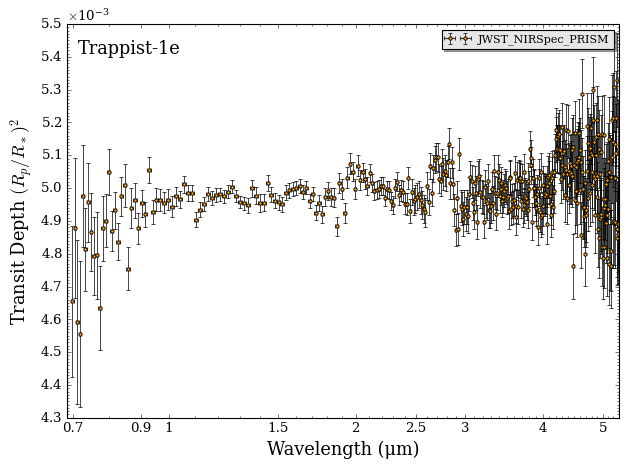

In [27]:
wl_model = wl_grid_constant_R(WL_MIN_UM, WL_MAX_UM, R_GRID)

data = load_data(
    str(DATA_DIR),
    datasets=[OBSERVATION_FILE],
    instruments=INSTRUMENTS,
    wl_model=wl_model,
)

fig_data = plot_data(data, PLANET_NAME)


## 3) Define the contaminated stellar model (two_spots) and priors


In [28]:
model = define_model(
    MODEL_NAME,
    BULK_SPECIES,
    PARAM_SPECIES,
    PT_profile="isotherm",
    cloud_model="cloud-free",
    stellar_contam="two_spots",
)

print("Free parameters:", model["param_names"])


prior_types = {
    "T": "uniform",
    "R_p_ref": "uniform",
    "log_H2O": "uniform",
    "log_CH4": "uniform",
    "log_CO2": "uniform",
    "log_O3": "uniform",
    "f_spot": "uniform",
    "f_fac": "uniform",
    "T_phot": "uniform",
    "T_fac": "uniform",
    "T_spot": "uniform",
}

prior_ranges = {
    "T": [200, 400],
    "R_p_ref": [0.85 * R_p, 1.15 * R_p],
    "log_H2O": [-8, -1],
    "log_CH4": [-8, -1],
    "log_CO2": [-5, -1],
    "log_O3": [-8, -1],
    "f_spot": [0.0, 0.26],
    "f_fac": [0.0, 0.70],
    "T_phot": [0.9 * T_s, 1.1 * T_s],
    "T_fac": [T_s, T_s + 15.0],
    "T_spot": [0.8 * T_s, 0.9 * T_s],
}

priors = set_priors(planet, star, model, data, prior_types, prior_ranges)


Free parameters: ['R_p_ref' 'T' 'log_H2O' 'log_CH4' 'log_CO2' 'log_O3' 'f_spot' 'f_fac'
 'T_spot' 'T_fac' 'T_phot']


## 4) Read opacities and precompute stellar spectra

The `precompute_stellar_spectra` call is required for `two_spots` contamination.


In [29]:
""" opacity_treatment = "opacity_sampling"

T_fine = np.arange(200, 401, 10)
log_P_fine = np.arange(-2, 2.0001, 0.2)

opac = read_opacities(model, wl_model, opacity_treatment, T_fine, log_P_fine)
 """

' opacity_treatment = "opacity_sampling"\n\nT_fine = np.arange(200, 401, 10)\nlog_P_fine = np.arange(-2, 2.0001, 0.2)\n\nopac = read_opacities(model, wl_model, opacity_treatment, T_fine, log_P_fine)\n '

## 5) Plot retrieved transmission spectrum and corner plot

This assumes retrieval outputs exist for `(PLANET_NAME, MODEL_NAME)`.


Generating corner plot ...


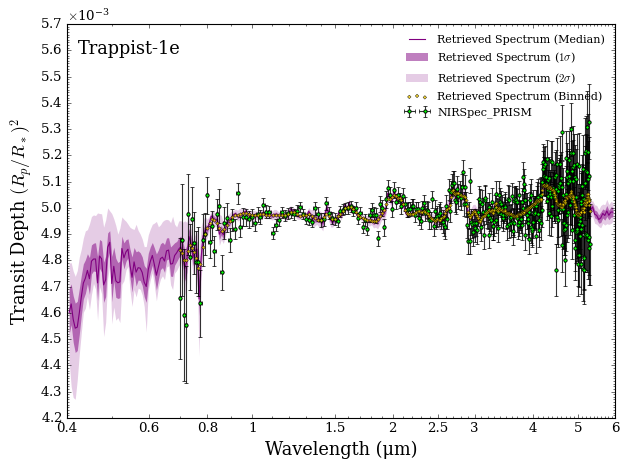

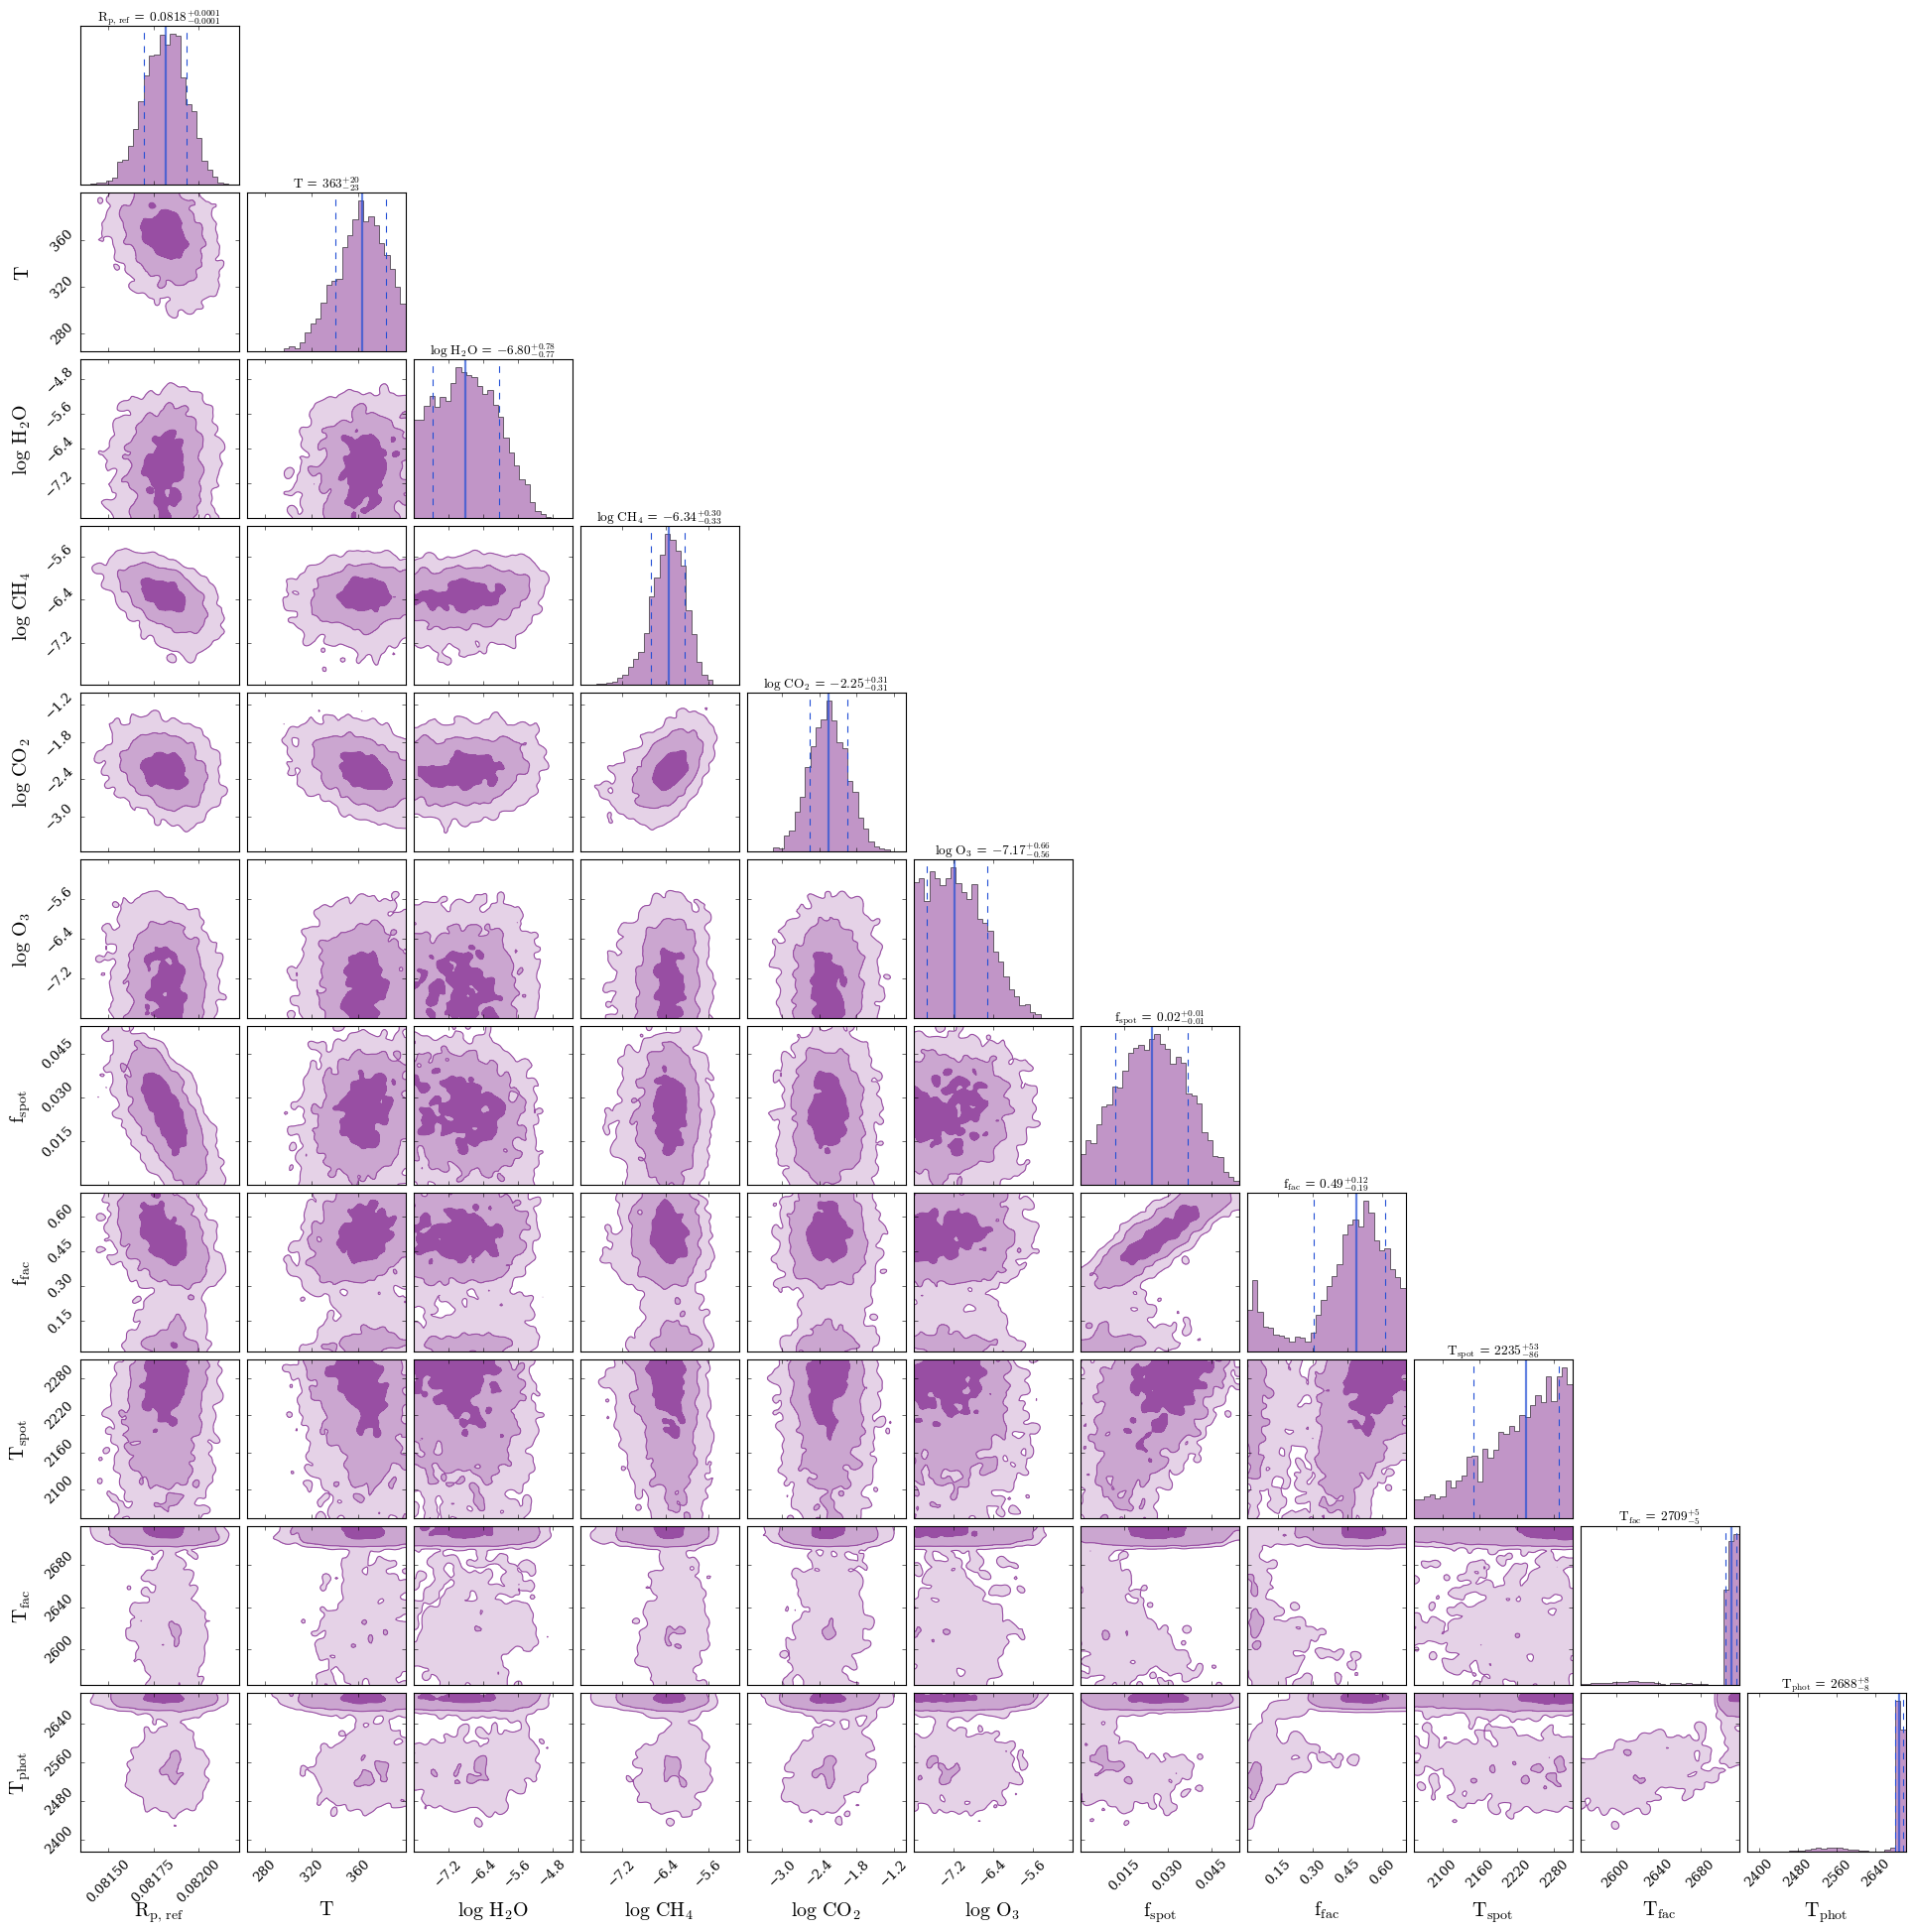

In [30]:
(
    wl_out,
    spec_low2,
    spec_low1,
    spec_median,
    spec_high1,
    spec_high2,
) = read_retrieved_spectrum(PLANET_NAME, MODEL_NAME)

spectra_median = plot_collection(spec_median, wl_out, collection=[])
spectra_low1 = plot_collection(spec_low1, wl_out, collection=[])
spectra_low2 = plot_collection(spec_low2, wl_out, collection=[])
spectra_high1 = plot_collection(spec_high1, wl_out, collection=[])
spectra_high2 = plot_collection(spec_high2, wl_out, collection=[])

fig_spec = plot_spectra_retrieved(
    spectra_median,
    spectra_low2,
    spectra_low1,
    spectra_high1,
    spectra_high2,
    PLANET_NAME,
    data,
    R_to_bin=100,
    data_labels=["NIRSpec_PRISM"],
    data_colour_list=["lime"],
)

fig_corner = generate_cornerplot(planet, model)


## 6) Manual contamination-correction step

No retrieval is run here.

This cell only rebuilds a PHOENIX star using stellar parameters that you already inferred in the completed retrieval, then evaluates the corresponding contamination factor $\epsilon(\lambda)$.


In [31]:
# -----------------------------
# IMPORTANT: manually update these after inspecting retrieval outputs
# -----------------------------
T_s_retrieved = 2688.0 # Τ_phot
f_spot_retrieved = 0.02
T_spot_retrieved = 2235.0
f_fac_retrieved = 0.49
T_fac_retrieved = 2709.0

star_retrieved = create_star(
    R_s,
    T_s_retrieved,
    log_g_s,
    met_s,
    stellar_grid="phoenix",
    stellar_contam="two_spots",
    f_spot=f_spot_retrieved,
    T_spot=T_spot_retrieved,
    f_fac=f_fac_retrieved,
    T_fac=T_fac_retrieved,
)

epsilon = stellar_contamination(star_retrieved, wl_out)
epsilon = np.asarray(epsilon, dtype=float)

print("Computed epsilon(lambda) for contamination correction.")


Computed epsilon(lambda) for contamination correction.


## 7) Metrics vs clean truth using contamination-corrected spectrum

The validation step below first removes the retrieved stellar contamination from the median retrieved spectrum and then averages both that corrected spectrum and `pandexo_spec.txt` directly over the observed wavelength bins `(wl_data, half_bin)`.
This mirrors the robust comparison now used in the G-DAE branch and helps prevent hidden binning inconsistencies.


In [32]:
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd


def load_clean_two_cols(path: str | Path) -> Tuple[np.ndarray, np.ndarray]:
    """Load a two-column clean spectrum file: (wl_um, depth)."""
    arr = np.genfromtxt(path, comments="#", dtype=float)

    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)

    if arr.shape[1] < 2:
        raise ValueError(
            "Expected >= 2 columns (wl_um, depth) in the clean spectrum file."
        )

    wl_clean = arr[:, 0].astype(float)
    y_clean = arr[:, 1].astype(float)

    idx = np.argsort(wl_clean)
    return wl_clean[idx], y_clean[idx]


def band_average_to_bins(
    wl_src: np.ndarray,
    y_src: np.ndarray,
    centers: np.ndarray,
    halfwidths: np.ndarray,
    nsamp: int = 256,
) -> np.ndarray:
    """Average a spectrum over explicit wavelength bins using trapezoidal integration."""
    wl_src = np.asarray(wl_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    centers = np.asarray(centers, dtype=float)
    halfwidths = np.asarray(halfwidths, dtype=float)

    sort_idx = np.argsort(wl_src)
    wl_sorted = wl_src[sort_idx]
    y_sorted = y_src[sort_idx]

    out = np.empty_like(centers, dtype=float)
    for i, (center, halfwidth) in enumerate(zip(centers, halfwidths)):
        a = center - halfwidth
        b = center + halfwidth
        x = np.linspace(a, b, nsamp)
        y = np.interp(x, wl_sorted, y_sorted)
        out[i] = np.trapz(y, x) / (b - a)

    return out


def append_metrics_to_csv(
    log_path: str | Path,
    planet_name: str,
    model_name: str,
    observation: str | None,
    metrics: dict,
    retrieval_strategy: str,
    metrics_basis: str,
) -> pd.DataFrame:
    """Append one metrics row to the CSV log using a fixed column order."""
    log_path = Path(log_path)

    columns = [
        "planet_name",
        "model_name",
        "observation",
        "retrieval_strategy",
        "metrics_basis",
        "N",
        "p",
        "dof",
        "MSE",
        "rmse",
        "rmse_ppm",
        "chi2",
        "chi2_reduced",
    ]

    row = {
        "planet_name": str(planet_name),
        "model_name": str(model_name),
        "observation": "" if observation is None else str(observation),
        "retrieval_strategy": str(retrieval_strategy),
        "metrics_basis": str(metrics_basis),
        "N": int(metrics["N"]),
        "p": int(metrics["p"]),
        "dof": int(metrics["dof"]),
        "MSE": float(metrics["MSE"]),
        "rmse": float(metrics["rmse"]),
        "rmse_ppm": float(metrics["rmse_ppm"]),
        "chi2": float(metrics["chi2"]),
        "chi2_reduced": float(metrics["chi2_reduced"]),
    }

    new_row_df = pd.DataFrame([row], columns=columns)

    if log_path.exists():
        df_log = pd.read_csv(log_path)

        for col in columns:
            if col not in df_log.columns:
                df_log[col] = np.nan

        df_log = df_log[columns]
        df_log = pd.concat([df_log, new_row_df], ignore_index=True)
    else:
        df_log = new_row_df

    df_log.to_csv(log_path, index=False, float_format="%.10g")
    print(f"Appended row to: {log_path.resolve()}")

    return df_log


wl_clean, y_clean = load_clean_two_cols(CLEAN_PATH)
wl_data, half_bin, y_obs, err_obs = read_data(str(DATA_DIR), OBSERVATION_FILE)

sort_idx = np.argsort(np.asarray(wl_data, dtype=float))
wl_data = np.asarray(wl_data, dtype=float)[sort_idx]
half_bin = np.asarray(half_bin, dtype=float)[sort_idx]
y_obs = np.asarray(y_obs, dtype=float)[sort_idx]
err_obs = np.asarray(err_obs, dtype=float)[sort_idx]

print(f"N observed points: {len(wl_data)}")
print(f"wl_data range    : {wl_data.min():.4f}–{wl_data.max():.4f} µm")

median_corrected = np.asarray(spec_median, dtype=float) / np.asarray(epsilon, dtype=float)

model_binned = band_average_to_bins(wl_out, median_corrected, wl_data, half_bin)
clean_binned = band_average_to_bins(wl_clean, y_clean, wl_data, half_bin)

if not (len(model_binned) == len(clean_binned) == len(err_obs)):
    raise ValueError("Binned arrays and uncertainties must have the same length.")

sig = np.asarray(err_obs, dtype=float)
if np.any(sig <= 0) or np.any(~np.isfinite(sig)):
    raise ValueError(
        "err_obs contains invalid uncertainties (non-positive or non-finite)."
    )

yhat = np.asarray(model_binned, dtype=float)
y = np.asarray(clean_binned, dtype=float)
resid = yhat - y

n_points = int(resid.size)
p = int(N_FREE_PARAMS)
dof = int(max(n_points - p, 0))

chi2 = float(np.sum((resid / sig) ** 2))
chi2_reduced = float(chi2 / dof) if dof > 0 else np.nan

mse = float(np.mean(resid**2))
rmse = float(np.sqrt(mse))
rmse_ppm = float(1e6 * rmse)

print("---- METRICS vs CLEAN TRUTH (corrected median / epsilon) ----")
print(f"N points     : {n_points}")
print(f"Params p     : {p}")
print(f"DoF          : {dof}")
print(f"MSE          : {mse:.6e}")
print(f"RMSE         : {rmse:.6e}  ({rmse_ppm:.2f} ppm)")
print(f"chi2         : {chi2:.6f}")
print(f"chi2_reduced : {chi2_reduced:.6f}")

metrics = {
    "N": n_points,
    "p": p,
    "dof": dof,
    "MSE": mse,
    "rmse": rmse,
    "rmse_ppm": rmse_ppm,
    "chi2": chi2,
    "chi2_reduced": chi2_reduced,
}

df_log = append_metrics_to_csv(
    log_path=LOG_PATH,
    planet_name=PLANET_NAME,
    model_name=MODEL_NAME,
    observation=OBSERVATION_FILE,
    metrics=metrics,
    retrieval_strategy=RETRIEVAL_STRATEGY,
    metrics_basis="median_retrieved_spectrum_divided_by_epsilon",
)


N observed points: 385
wl_data range    : 0.6988–5.2976 µm
---- METRICS vs CLEAN TRUTH (corrected median / epsilon) ----
N points     : 385
Params p     : 11
DoF          : 374
MSE          : 8.688825e-10
RMSE         : 2.947681e-05  (29.48 ppm)
chi2         : 184.446337
chi2_reduced : 0.493172
Appended row to: /mnt/c/Proyectos/Astro/gdaespec/Earth_like_Atmosphere/Retrieval Tests/sphinx_injection/chi2_log_sphinx.csv


## Visual validation of the spectral comparison

This plot overlays the observed spectrum, the clean truth averaged over the observed bins, and the contamination-corrected retrieved median averaged over the same bins.
The lower panel shows residuals in ppm with a zoomed vertical range so small differences remain visible.


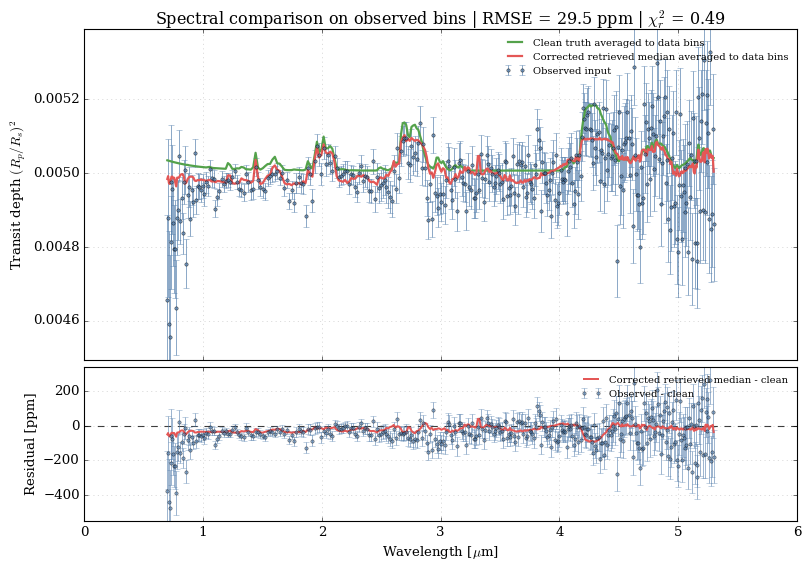

In [33]:
import matplotlib.pyplot as plt

obs_minus_clean_ppm = 1.0e6 * (np.asarray(y_obs, dtype=float) - np.asarray(clean_binned, dtype=float))
model_minus_clean_ppm = 1.0e6 * resid
err_ppm = 1.0e6 * np.asarray(err_obs, dtype=float)

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.4]},
    constrained_layout=True,
)

ax_top.errorbar(
    wl_data,
    y_obs,
    yerr=err_obs,
    fmt="o",
    ms=3.0,
    lw=0.8,
    alpha=0.7,
    color="#4c78a8",
    label="Observed input",
)
ax_top.plot(
    wl_data,
    clean_binned,
    color="#54a24b",
    lw=2.0,
    label="Clean truth averaged to data bins",
)
ax_top.plot(
    wl_data,
    model_binned,
    color="#e45756",
    lw=2.0,
    label="Corrected retrieved median averaged to data bins",
)

y_top = np.concatenate([
    np.asarray(y_obs, dtype=float),
    np.asarray(clean_binned, dtype=float),
    np.asarray(model_binned, dtype=float),
])
y_margin = max(5.0e-6, 0.08 * (float(y_top.max()) - float(y_top.min())))
ax_top.set_ylim(float(y_top.min()) - y_margin, float(y_top.max()) + y_margin)

ax_top.set_ylabel(r"Transit depth $(R_p/R_s)^2$")
ax_top.set_title(
    f"Spectral comparison on observed bins | RMSE = {rmse_ppm:.1f} ppm | $\chi^2_r$ = {chi2_reduced:.2f}"
)
ax_top.grid(alpha=0.25)
ax_top.legend(frameon=False, fontsize=9)

ax_bottom.axhline(0.0, color="0.25", lw=1.0, ls="--")
ax_bottom.errorbar(
    wl_data,
    obs_minus_clean_ppm,
    yerr=err_ppm,
    fmt="o",
    ms=3.0,
    lw=0.8,
    alpha=0.6,
    color="#4c78a8",
    label="Observed - clean",
)
ax_bottom.plot(
    wl_data,
    model_minus_clean_ppm,
    color="#e45756",
    lw=1.8,
    label="Corrected retrieved median - clean",
)

y_bottom = np.concatenate([obs_minus_clean_ppm, model_minus_clean_ppm, err_ppm, -err_ppm])
y_bottom_margin = max(10.0, 0.1 * (float(y_bottom.max()) - float(y_bottom.min())))
ax_bottom.set_ylim(float(y_bottom.min()) - y_bottom_margin, float(y_bottom.max()) + y_bottom_margin)

ax_bottom.set_xlabel(r"Wavelength [$\mu$m]")
ax_bottom.set_ylabel("Residual [ppm]")
ax_bottom.grid(alpha=0.25)
ax_bottom.legend(frameon=False, fontsize=9)

plt.show()
